In [1]:
from path import Path

root = Path(r'/home/flo/repos/SystemSimulation/demos/ControlledPendulum/')
pkg_dir = Path(root / "ControlledPendulum")
pkg_str = str(root / "ControlledPendulum" / "package.mo")
pkg_name = "ControlledPendulum"

model_names = Path(pkg_dir).files("*.mo")
model_names = [m.stem for m in model_names if m.stem != "package"]

for model_name in model_names:
    print(f"Found model: {model_name}")

Found model: PID_Cont
Found model: PIDController
Found model: DemoModel
Found model: Drive
Found model: Pendulum
Found model: ReferenceTrajectory
Found model: Sensor


In [2]:
from OMPython import ModelicaSystem
import shutil

def create_modelica_system(model_name):
    model = ModelicaSystem(pkg_str, model_name, verbose=True)
    return model

model_name = pkg_name + "." + "DemoModel"
demo_model = create_modelica_system(model_name)
demo_model.buildModel()


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




In [3]:
# Print parameters of the model
parameters = demo_model.getParameters()
print(f"Model parameters:")
for param in parameters:
    print(f"  {param}: {parameters[param]}")

Model parameters:
  drive.L_M: 1.21e-4
  drive.R_M: 0.151
  drive.U_M: 16.0
  drive.U_rated: 48.0
  drive.eta_M: 0.85
  drive.k_M: 0.03
  drive.k_n: None
  drive.n_0: 12916.0
  pendulum.L: 0.4
  pendulum.g: 9.81
  pendulum.m: 16.0
  pendulum.q0: -1.5707963267948966
  pid.D.T: None
  pid.D.k: None
  pid.D.x_start: None
  pid.D.y_start: 0.0
  pid.I.k: None
  pid.I.y_start: None
  pid.Nd: 10.0
  pid.P.k: 1.0
  pid.Td: 0.1
  pid.Ti: 0.5
  pid.addErr.k1: 1.0
  pid.addErr.k2: -1.0
  pid.gainK.k: None
  pid.k: 1.0
  pid.lim.uMax: None
  pid.lim.uMin: None
  pid.sumPID.k1: 1.0
  pid.sumPID.k2: 1.0
  pid.sumPID.k3: 1.0
  pid.uMax: 1.0
  pid.uMin: -1.0
  pid.xd_start: 0.0
  pid.xi_start: 0.0
  reference.amplitude: 0.3490658503988659
  reference.mean: 0.0
  sensor_ref.R3: 8e4
  sensor_ref.R4: 2e4
  sensor_ref.U_0_pot: 5.0
  sensor_ref.U_ADC: 3.0
  sensor_ref.alpha_max: 4.71238898038469
  sensor_ref.delta: None
  sensor_ref.levels: None
  sensor_ref.nBits: 8.0
  sensor_ref.q_max: 0.349065850398865

In [18]:
# Set simulation parameters
simulation_options = [
    "startTime=0.0",
    "stopTime=20.0",        
    "stepSize=0.01",
    "tolerance=1e-6"
]

demo_model.setSimulationOptions(simulation_options)
current_options = demo_model.getSimulationOptions()
print(f"Simulation options:")
for option in current_options:
    print(f"  {option}: {current_options[option]}")

Simulation options:
  startTime: 0.0
  stopTime: 20.0
  stepSize: 0.01
  tolerance: 1e-6
  solver: dassl
  outputFormat: mat


In [19]:
# Run simulation
print("Running simulation...")
demo_model.simulate()
print("Simulation completed successfully")

Running simulation...
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
Simulation completed successfully


In [20]:
# Extract results
results = demo_model.getSolutions()

In [21]:
results

('der(pendulum.omega)',
 'der(pendulum.q)',
 'drive.L_M',
 'drive.R_M',
 'drive.U_M',
 'drive.U_rated',
 'drive.eta_M',
 'drive.i_M',
 'drive.k_M',
 'drive.k_n',
 'drive.n_0',
 'drive.omega',
 'drive.torque',
 'drive.u_control',
 'pendulum.L',
 'pendulum.g',
 'pendulum.m',
 'pendulum.omega',
 'pendulum.omega_state',
 'pendulum.q',
 'pendulum.q0',
 'pendulum.q_state',
 'pendulum.torque',
 'pid.Nd',
 'pid.Td',
 'pid.Ti',
 'pid.k',
 'pid.ref',
 'pid.u',
 'pid.uMax',
 'pid.uMin',
 'pid.xd_start',
 'pid.xi_start',
 'pid.y',
 'reference.amplitude',
 'reference.mean',
 'reference.q_ref',
 'sensor_ref.R3',
 'sensor_ref.R4',
 'sensor_ref.U_0_pot',
 'sensor_ref.U_ADC',
 'sensor_ref.U_q',
 'sensor_ref.alpha_max',
 'sensor_ref.delta',
 'sensor_ref.levels',
 'sensor_ref.nBits',
 'sensor_ref.q',
 'sensor_ref.q_max',
 'sensor_ref.q_min',
 'sensor_state.R3',
 'sensor_state.R4',
 'sensor_state.U_0_pot',
 'sensor_state.U_ADC',
 'sensor_state.U_q',
 'sensor_state.alpha_max',
 'sensor_state.delta',
 'sens

In [22]:
time_values = demo_model.getSolutions('time')
ref_values = demo_model.getSolutions('reference.q_ref')
state_values = demo_model.getSolutions('pendulum.q_state')

In [23]:
time_values = time_values.flatten()
ref_values = ref_values.flatten()
state_values = state_values.flatten()

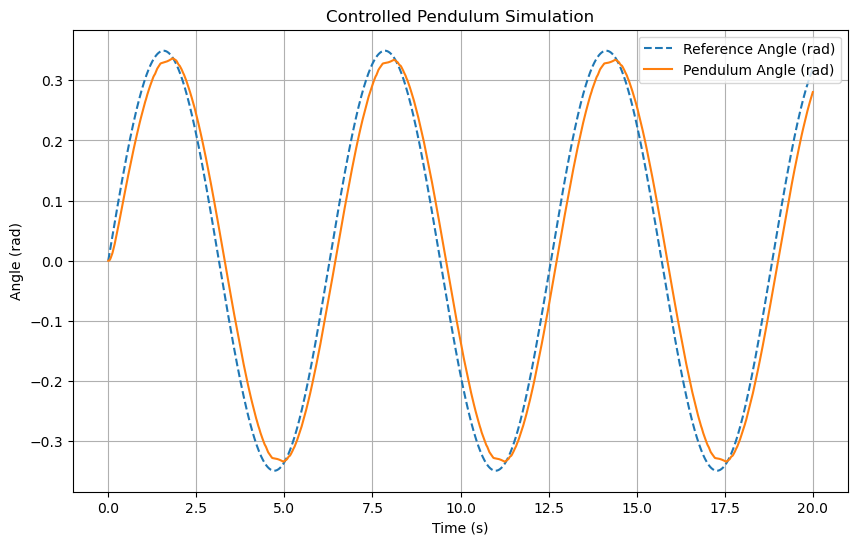

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(time_values, ref_values, label='Reference Angle (rad)', linestyle='--')
plt.plot(time_values, state_values, label='Pendulum Angle (rad)')
plt.title('Controlled Pendulum Simulation')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.legend()
plt.grid()
plt.show()